# AG-UNet — Model Evaluation & Visual Results
**Purpose:** Load the saved best model checkpoint and evaluate on the validation set.

Produces:
- Full metrics table: Dice, IoU, Precision, Recall, Specificity, HD95
- Per-sample metric distribution plots
- Visual proof panels: CT | Ground Truth | Prediction | Overlay
- Attention gate heatmaps
- Failure case analysis

> **Before running:** set `CHECKPOINT_PATH` and `DATA_DIR` in Cell 2.

## 1. Install Dependencies

In [1]:
!pip install torch torchvision numpy scipy matplotlib scikit-image tqdm -q

## 2. Configuration

In [2]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── CHANGE THESE TWO PATHS ────────────────────────────────────────────────────
CHECKPOINT_PATH = 'outputs/best_model.pth'   # path to your saved checkpoint
DATA_DIR        = 'dataset'                   # path to your dataset folder
# ─────────────────────────────────────────────────────────────────────────────

EVAL_SPLIT   = 'val'      # 'val' or 'train'
THRESHOLD    = 0.5        # sigmoid threshold for binary prediction
N_VISUAL     = 12         # number of visual proof panels to generate
OUTPUT_DIR   = 'eval_results'
FEATURES     = [64, 128, 256, 512]
IN_CHANNELS  = 1
BATCH_SIZE   = 16

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42); random.seed(42)

print(f'Device       : {DEVICE}')
print(f'Checkpoint   : {CHECKPOINT_PATH}')
print(f'Dataset      : {DATA_DIR}/{EVAL_SPLIT}')
print(f'Output dir   : {OUTPUT_DIR}/')

Device       : cuda
Checkpoint   : outputs/best_model.pth
Dataset      : dataset/val
Output dir   : eval_results/


## 3. Dataset Loader

In [3]:
class LungTumorDataset(Dataset):
    def __init__(self, root_dir, split='val', augment=False):
        self.samples = []
        split_dir = os.path.join(root_dir, split)
        patient_folders = sorted(os.listdir(split_dir))
        for patient in patient_folders:
            data_dir = os.path.join(split_dir, patient, 'data')
            mask_dir = os.path.join(split_dir, patient, 'masks')
            if not os.path.isdir(data_dir) or not os.path.isdir(mask_dir): continue
            for df, mf in zip(sorted(os.listdir(data_dir)), sorted(os.listdir(mask_dir))):
                self.samples.append((os.path.join(data_dir, df), os.path.join(mask_dir, mf)))
        print(f'[{split}] {len(self.samples)} slices from {len(patient_folders)} patients.')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        data_path, mask_path = self.samples[idx]
        image = np.load(data_path).astype(np.float32)
        mask  = np.load(mask_path).astype(np.float32)
        if image.ndim == 3 and image.shape[0] > 3:
            mid = image.shape[0] // 2
            image = image[mid]; mask = mask[mid]
        xmin, xmax = image.min(), image.max()
        image = (image - xmin) / (xmax - xmin + 1e-6)
        if image.ndim == 3: image = image[0]
        if mask.ndim  == 3: mask  = mask[0]
        image = image[np.newaxis]; mask = mask[np.newaxis]
        mask  = (mask > 0.5).astype(np.float32)
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


dataset = LungTumorDataset(DATA_DIR, split=EVAL_SPLIT, augment=False)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Batches: {len(loader)}')

[val] 1335 slices from 6 patients.
Batches: 84


## 4. Model Architecture

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.shape
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l,  F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g); x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))

class AGUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64,128,256,512], dropout=0.1):
        super().__init__()
        self.downs = nn.ModuleList(); self.ups = nn.ModuleList()
        self.att_gates = nn.ModuleList(); self.se_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat, dropout))
            self.se_blocks.append(SEBlock(feat)); ch = feat
        self.bottleneck = DoubleConv(features[-1], features[-1]*2, dropout)
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat*2, feat, 2, stride=2))
            self.att_gates.append(AttentionGate(feat, feat, feat//2))
            self.ups.append(DoubleConv(feat*2, feat, dropout))
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)
    def forward(self, x):
        skips = []
        for down, se in zip(self.downs, self.se_blocks):
            x = down(x); x = se(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([self.att_gates[i//2](g=x, x=skip), x], dim=1)
            x = self.ups[i+1](x)
        return self.final_conv(x)


# Load checkpoint
model = AGUNet(in_channels=IN_CHANNELS, features=FEATURES).to(DEVICE)
ckpt  = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Checkpoint loaded from epoch : {ckpt["epoch"]}')
print(f'Best val Dice (training)     : {ckpt["val_dice"]:.4f}')
print(f'Total parameters             : {sum(p.numel() for p in model.parameters()):,}')

Checkpoint loaded from epoch : 26
Best val Dice (training)     : 0.9456
Total parameters             : 31,430,569


## 5. Metric Functions

In [5]:
def dice_coeff(pred, target, smooth=1e-6):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    return (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    inter = (p*t).sum()
    return (inter + smooth) / (p.sum() + t.sum() - inter + smooth)

def prec_rec_spec(pred, target):
    p, t = pred.flatten().astype(float), target.flatten().astype(float)
    # Skip empty slices where no tumour is present
    if t.sum() == 0 and p.sum() == 0: return 1.0, 1.0, 1.0
    if t.sum() == 0: return 0.0, 1.0, 1.0
    TP = (p*t).sum(); FP = (p*(1-t)).sum()
    FN = ((1-p)*t).sum(); TN = ((1-p)*(1-t)).sum()
    return TP/(TP+FP+1e-6), TP/(TP+FN+1e-6), TN/(TN+FP+1e-6)

def hd95(pred, target):
    pp = np.argwhere(pred > 0).astype(float)
    tp = np.argwhere(target > 0).astype(float)
    if len(pp) == 0 and len(tp) == 0: return 0.0
    if len(pp) == 0 or  len(tp) == 0: return np.inf
    d1, _ = cKDTree(pp).query(tp)
    d2, _ = cKDTree(tp).query(pp)
    return float(np.percentile(np.concatenate([d1, d2]), 95))

print('Metric functions ready ✓')

Metric functions ready ✓


## 6. Full Dataset Evaluation

In [6]:
all_dice  = []; all_iou   = []; all_prec  = []
all_rec   = []; all_spec  = []; all_hd95  = []
all_images= []; all_masks = []; all_probs = []  # store for visualisation

model.eval()
with torch.no_grad():
    for images, masks in tqdm(loader, desc='Evaluating'):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).float()

        # Store for visualisation (keep on CPU)
        all_images.append(images.cpu().numpy())
        all_masks.append(masks.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

        # Per-sample metrics
        preds_np  = preds.cpu().numpy().astype(np.uint8)
        masks_np  = masks.cpu().numpy().astype(np.uint8)
        probs_np  = probs.cpu().numpy()

        for b in range(preds_np.shape[0]):
            p, t = preds_np[b, 0], masks_np[b, 0]
            all_dice.append(dice_coeff(p, t))
            all_iou.append(iou_score(p, t))
            pr, re, sp = prec_rec_spec(p, t)
            all_prec.append(pr); all_rec.append(re); all_spec.append(sp)
            all_hd95.append(hd95(p, t))

# Flatten stored arrays
all_images = np.concatenate(all_images, axis=0)  # (N, 1, H, W)
all_masks  = np.concatenate(all_masks,  axis=0)
all_probs  = np.concatenate(all_probs,  axis=0)

hd95_finite = [h for h in all_hd95 if np.isfinite(h)]

results = {
    'Dice (DSC)'      : np.mean(all_dice),
    'IoU (Jaccard)'   : np.mean(all_iou),
    'Precision'       : np.mean(all_prec),
    'Recall'          : np.mean(all_rec),
    'Specificity'     : np.mean(all_spec),
    'HD95 (px)'       : np.mean(hd95_finite) if hd95_finite else float('inf'),
}

print('\n' + '='*52)
print('   EVALUATION RESULTS  —  AG-UNet')
print(f'   Checkpoint: Epoch {ckpt["epoch"]} | Split: {EVAL_SPLIT}')
print('='*52)
for k, v in results.items():
    bar = '█' * int(v * 20) if v <= 1 else ''
    print(f'  {k:<20}: {v:.4f}  {bar}')
print('='*52)
print(f'  Total slices evaluated : {len(all_dice)}')
print(f'  Slices with tumour     : {sum(1 for t in all_masks if t.sum() > 0)}')
print(f'  Empty slices (no GT)   : {sum(1 for t in all_masks if t.sum() == 0)}')
print('='*52)

Evaluating: 100%|██████████| 84/84 [00:59<00:00,  1.41it/s]



   EVALUATION RESULTS  —  AG-UNet
   Checkpoint: Epoch 26 | Split: val
  Dice (DSC)          : 0.9456  ██████████████████
  IoU (Jaccard)       : 0.9393  ██████████████████
  Precision           : 0.9523  ███████████████████
  Recall              : 0.9603  ███████████████████
  Specificity         : 1.0000  ███████████████████
  HD95 (px)           : 0.1624  ███
  Total slices evaluated : 1335
  Slices with tumour     : 101
  Empty slices (no GT)   : 1234


## 7. Per-Sample Metric Distributions

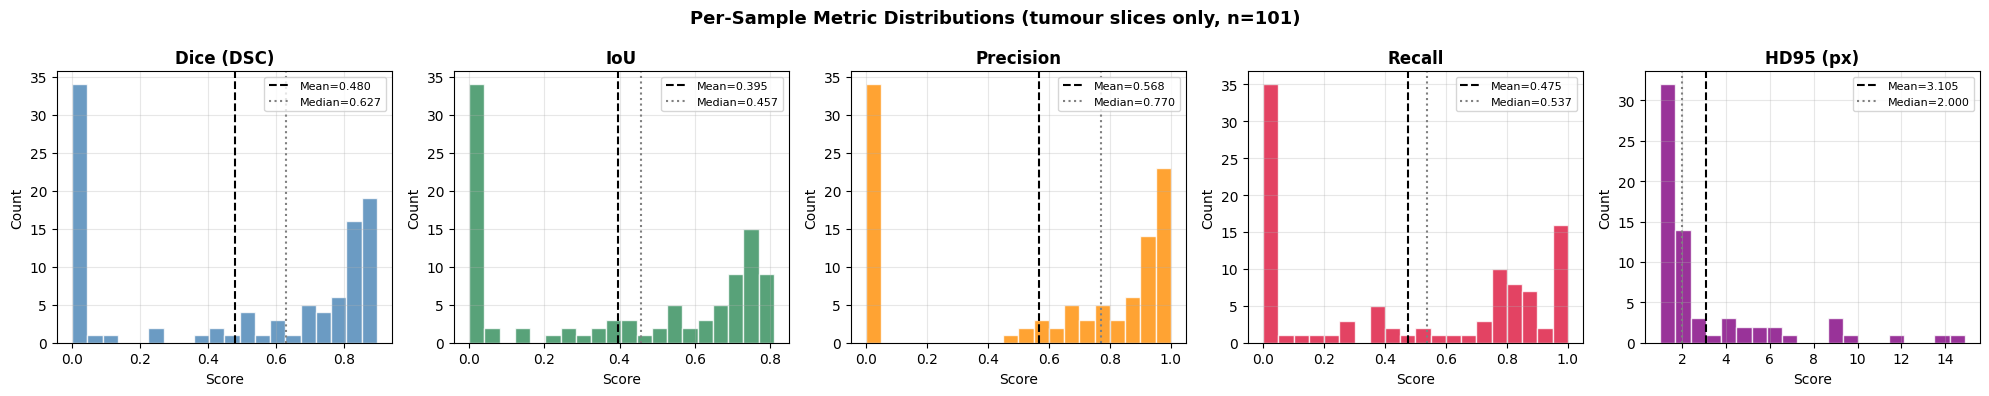

Saved: metric_distributions.png


In [7]:
# Only plot metrics for slices that have ground-truth tumour
tumour_idx = [i for i, m in enumerate(all_masks) if m.sum() > 0]

dice_t  = [all_dice[i]  for i in tumour_idx]
iou_t   = [all_iou[i]   for i in tumour_idx]
prec_t  = [all_prec[i]  for i in tumour_idx]
rec_t   = [all_rec[i]   for i in tumour_idx]
hd95_t  = [all_hd95[i]  for i in tumour_idx if np.isfinite(all_hd95[i])]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'Per-Sample Metric Distributions (tumour slices only, n={len(tumour_idx)})',
             fontsize=13, fontweight='bold')

configs = [
    (dice_t, 'Dice (DSC)',    'steelblue'),
    (iou_t,  'IoU',           'seagreen'),
    (prec_t, 'Precision',     'darkorange'),
    (rec_t,  'Recall',        'crimson'),
    (hd95_t, 'HD95 (px)',     'purple'),
]
for ax, (data, label, color) in zip(axes, configs):
    ax.hist(data, bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={np.mean(data):.3f}')
    ax.axvline(np.median(data), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median={np.median(data):.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metric_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metric_distributions.png')

## 8. Visual Proof — Ground Truth vs Prediction
Each panel shows: **CT Slice | Ground Truth | Predicted Probability | Overlay**

Overlay colours: 🟡 **Yellow = True Positive** | 🔴 **Red = False Positive** | 🔵 **Blue = False Negative**

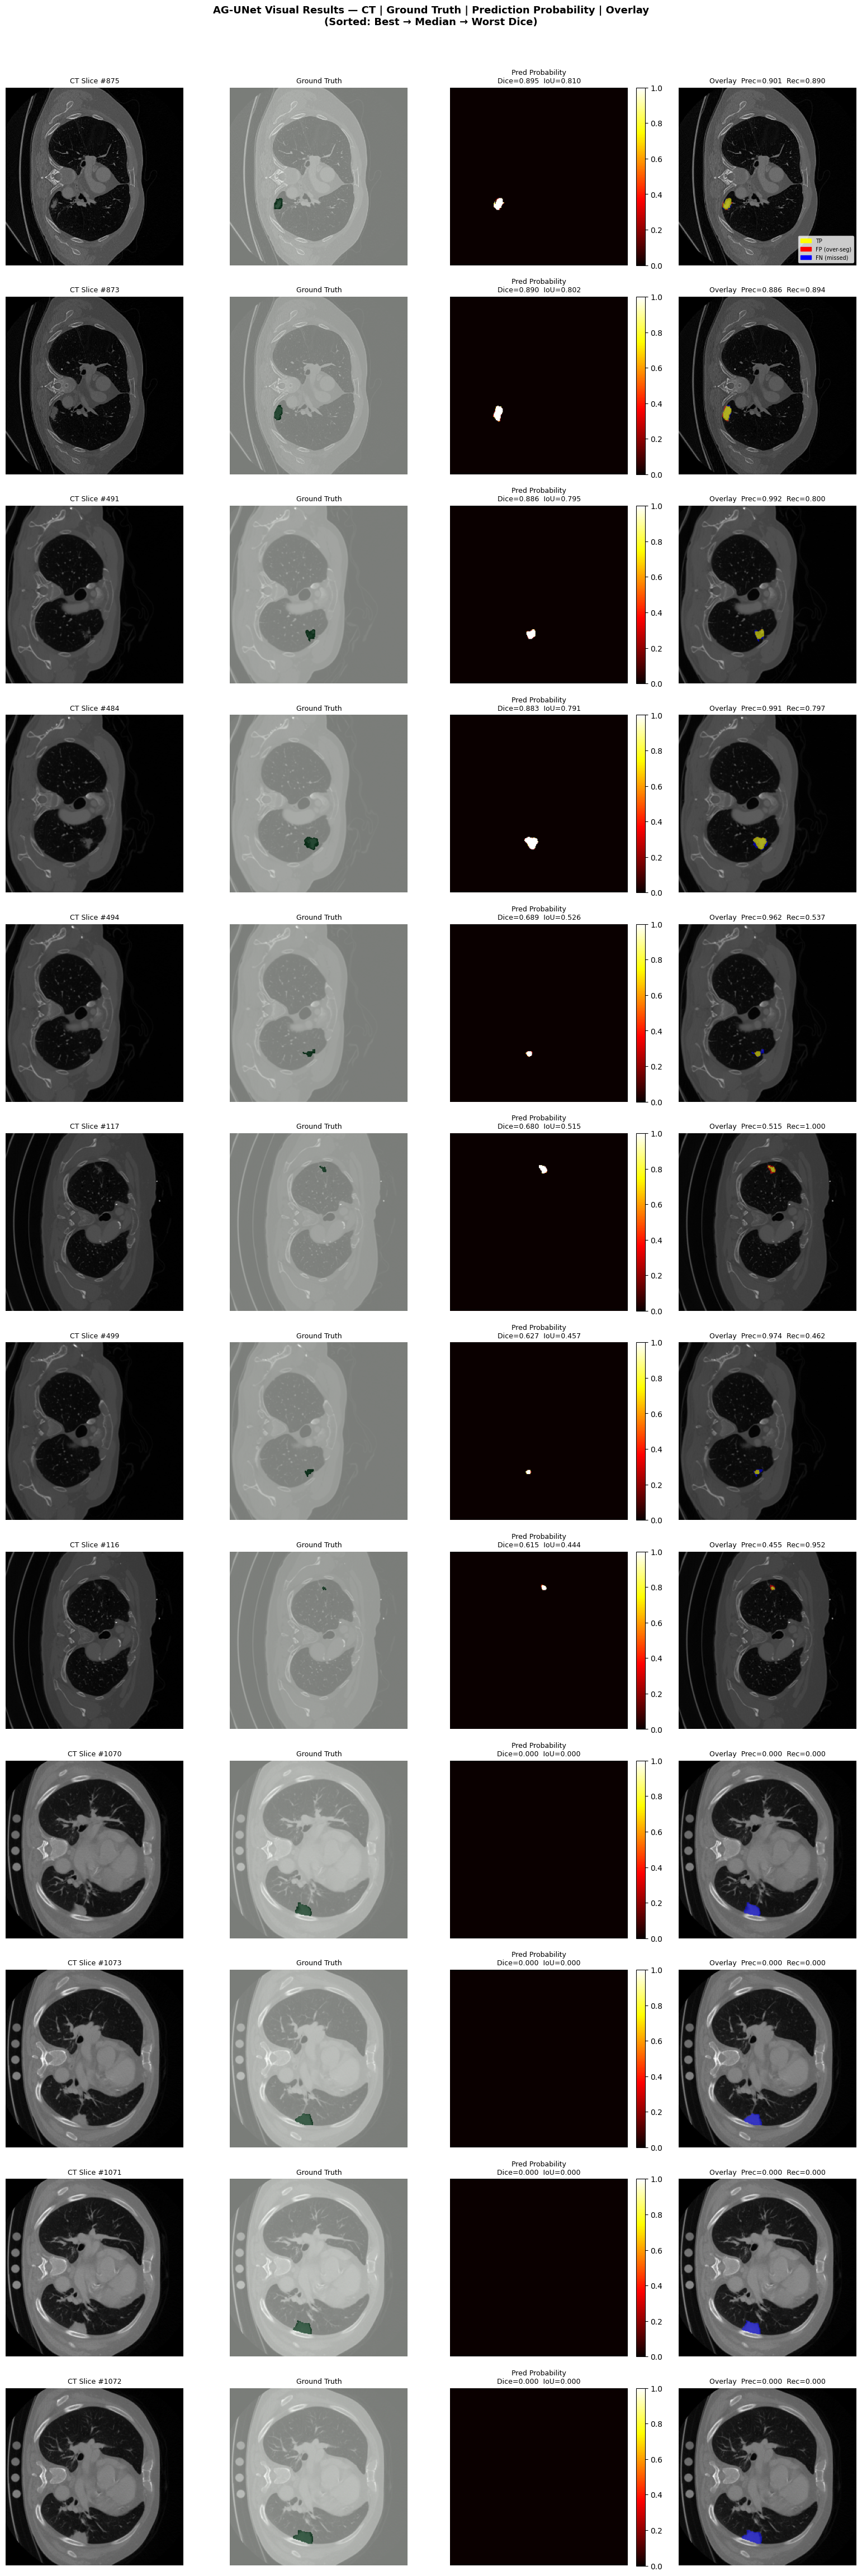

Saved: eval_results\visual_proof.png


In [8]:
def make_overlay(img, pred_bin, gt, alpha=0.45):
    rgb = np.stack([img, img, img], axis=-1).copy()
    tp = (pred_bin > 0) & (gt > 0)
    fp = (pred_bin > 0) & (gt == 0)
    fn = (pred_bin == 0) & (gt > 0)
    for ch, tv, fv, nv in zip([0,1,2], [1,1,0], [1,0,0], [0,0,1]):
        rgb[tp, ch] = alpha*rgb[tp, ch] + (1-alpha)*tv
        rgb[fp, ch] = alpha*rgb[fp, ch] + (1-alpha)*fv
        rgb[fn, ch] = alpha*rgb[fn, ch] + (1-alpha)*nv
    return np.clip(rgb, 0, 1)


# Pick N_VISUAL samples that HAVE ground-truth tumour for meaningful visual proof
tumour_indices = [i for i, m in enumerate(all_masks) if m[0].sum() > 0]
if len(tumour_indices) == 0:
    print('No tumour slices found — showing random samples instead')
    tumour_indices = list(range(len(all_masks)))

# Sort by Dice score so we get best / median / worst examples
tumour_dice   = [(i, all_dice[i]) for i in tumour_indices]
tumour_dice.sort(key=lambda x: x[1], reverse=True)

n = min(N_VISUAL, len(tumour_dice))
# Pick from top, middle, and bottom thirds for diversity
top    = [tumour_dice[i][0] for i in range(0,          n//3)]
mid    = [tumour_dice[i][0] for i in range(len(tumour_dice)//2 - n//6,
                                            len(tumour_dice)//2 + n//6)]
bottom = [tumour_dice[i][0] for i in range(len(tumour_dice)-n//3, len(tumour_dice))]
selected = (top + mid + bottom)[:n]

ncols = 4
nrows = len(selected)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.8))
if nrows == 1: axes = axes[np.newaxis]

fig.suptitle(
    'AG-UNet Visual Results — CT | Ground Truth | Prediction Probability | Overlay\n'
    '(Sorted: Best → Median → Worst Dice)',
    fontsize=13, fontweight='bold', y=1.01
)

for row, idx in enumerate(selected):
    img_np  = all_images[idx, 0]
    mask_np = all_masks[idx, 0].astype(np.uint8)
    prob_np = all_probs[idx, 0]
    pred_np = (prob_np > THRESHOLD).astype(np.uint8)
    overlay = make_overlay(img_np, pred_np, mask_np)

    dsc  = all_dice[idx]
    iou  = all_iou[idx]
    prec = all_prec[idx]
    rec  = all_rec[idx]

    # CT
    axes[row,0].imshow(img_np,  cmap='gray')
    axes[row,0].set_title(f'CT Slice #{idx}', fontsize=9)

    # GT
    axes[row,1].imshow(img_np, cmap='gray')
    axes[row,1].imshow(mask_np, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
    axes[row,1].set_title('Ground Truth', fontsize=9)

    # Probability map
    im = axes[row,2].imshow(prob_np, cmap='hot', vmin=0, vmax=1)
    axes[row,2].set_title(f'Pred Probability\nDice={dsc:.3f}  IoU={iou:.3f}', fontsize=9)
    plt.colorbar(im, ax=axes[row,2], fraction=0.046, pad=0.04)

    # Overlay
    axes[row,3].imshow(overlay)
    axes[row,3].set_title(f'Overlay  Prec={prec:.3f}  Rec={rec:.3f}', fontsize=9)

    # Legend on first row only
    if row == 0:
        patches = [mpatches.Patch(color='yellow', label='TP'),
                   mpatches.Patch(color='red',    label='FP (over-seg)'),
                   mpatches.Patch(color='blue',   label='FN (missed)')]
        axes[row,3].legend(handles=patches, loc='lower right', fontsize=7)

    # Row label
    rank = 'BEST' if row < n//3 else ('MEDIAN' if row < 2*n//3 else 'WORST')
    axes[row,0].set_ylabel(rank, fontsize=9, fontweight='bold',
                            color='green' if rank=='BEST' else ('orange' if rank=='MEDIAN' else 'red'))

    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'visual_proof.png')
plt.savefig(save_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 9. Failure Case Analysis
Displays the **5 worst-performing slices** that have ground truth — useful for identifying model weaknesses.

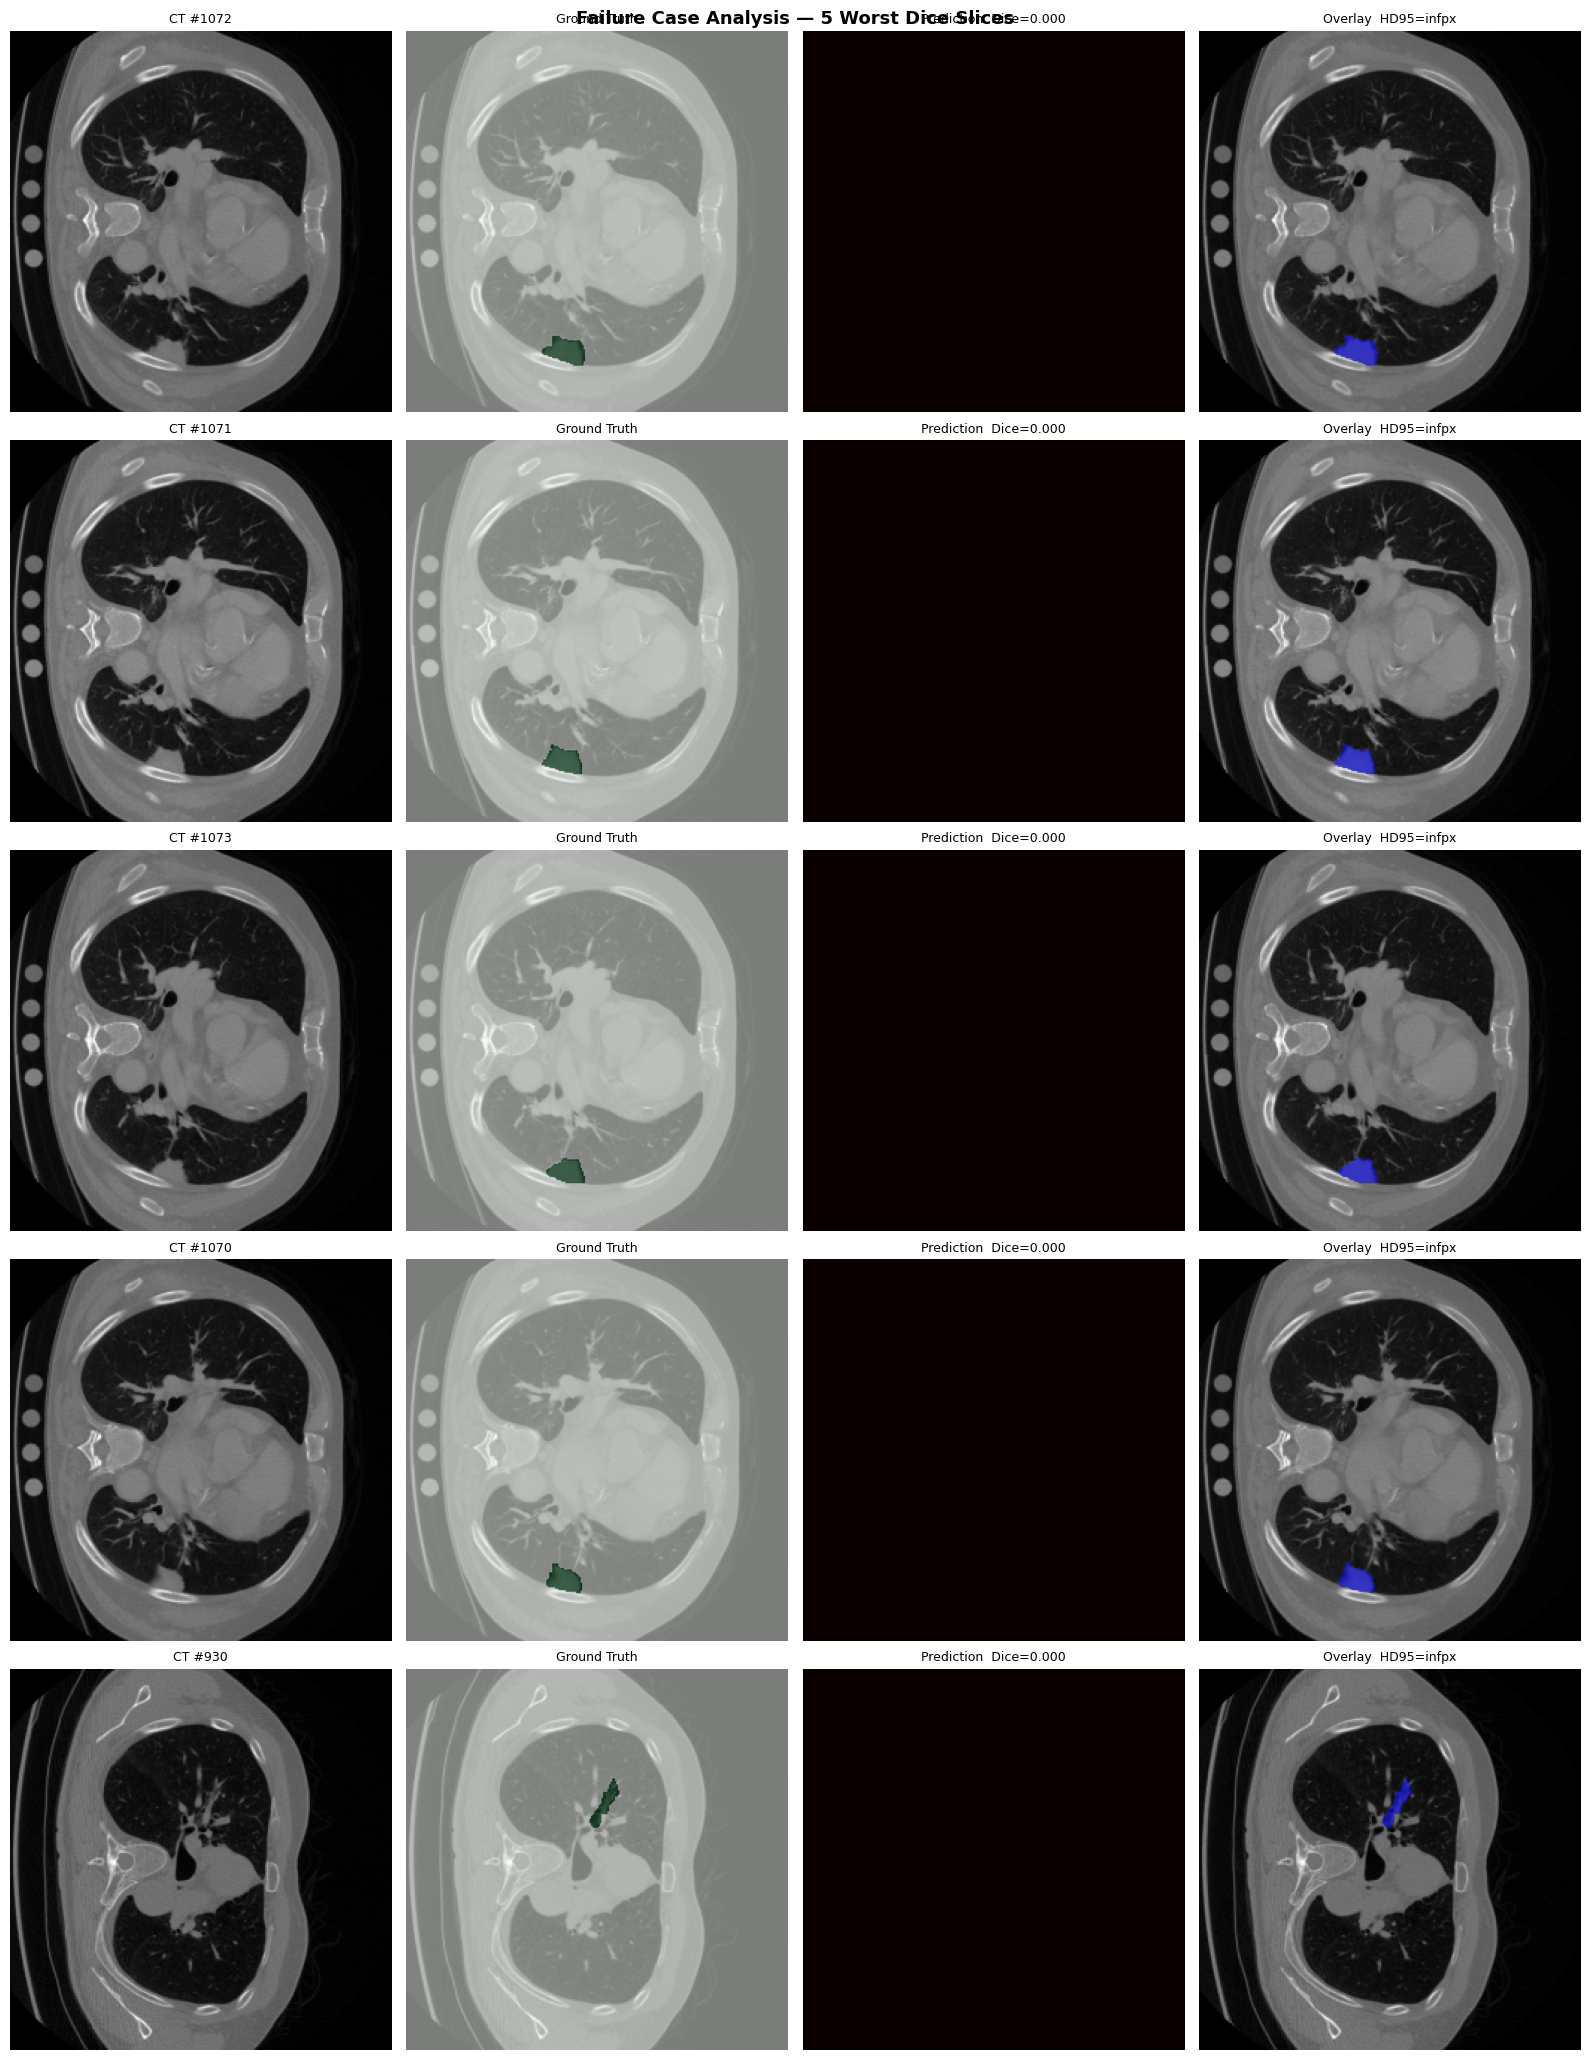

Saved: failure_cases.png


In [9]:
worst_5 = [tumour_dice[-(i+1)][0] for i in range(min(5, len(tumour_dice)))]

fig, axes = plt.subplots(5, 4, figsize=(16, 21))
fig.suptitle('Failure Case Analysis — 5 Worst Dice Slices', fontsize=13, fontweight='bold')

for row, idx in enumerate(worst_5):
    img_np  = all_images[idx, 0]
    mask_np = all_masks[idx, 0].astype(np.uint8)
    prob_np = all_probs[idx, 0]
    pred_np = (prob_np > THRESHOLD).astype(np.uint8)
    overlay = make_overlay(img_np, pred_np, mask_np)

    dsc  = all_dice[idx]
    h    = all_hd95[idx]
    hstr = f'{h:.1f}' if np.isfinite(h) else 'inf'

    axes[row,0].imshow(img_np, cmap='gray')
    axes[row,0].set_title(f'CT #{idx}', fontsize=9)

    axes[row,1].imshow(img_np, cmap='gray')
    axes[row,1].imshow(mask_np, cmap='Greens', alpha=0.5)
    axes[row,1].set_title('Ground Truth', fontsize=9)

    axes[row,2].imshow(prob_np, cmap='hot', vmin=0, vmax=1)
    axes[row,2].set_title(f'Prediction  Dice={dsc:.3f}', fontsize=9)

    axes[row,3].imshow(overlay)
    axes[row,3].set_title(f'Overlay  HD95={hstr}px', fontsize=9)

    axes[row,0].set_ylabel(f'#{row+1} Worst', fontsize=9, fontweight='bold', color='red')
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'failure_cases.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Saved: failure_cases.png')

## 10. Attention Gate Visualisation
Shows what spatial regions each attention gate focuses on — visual explainability for the paper.

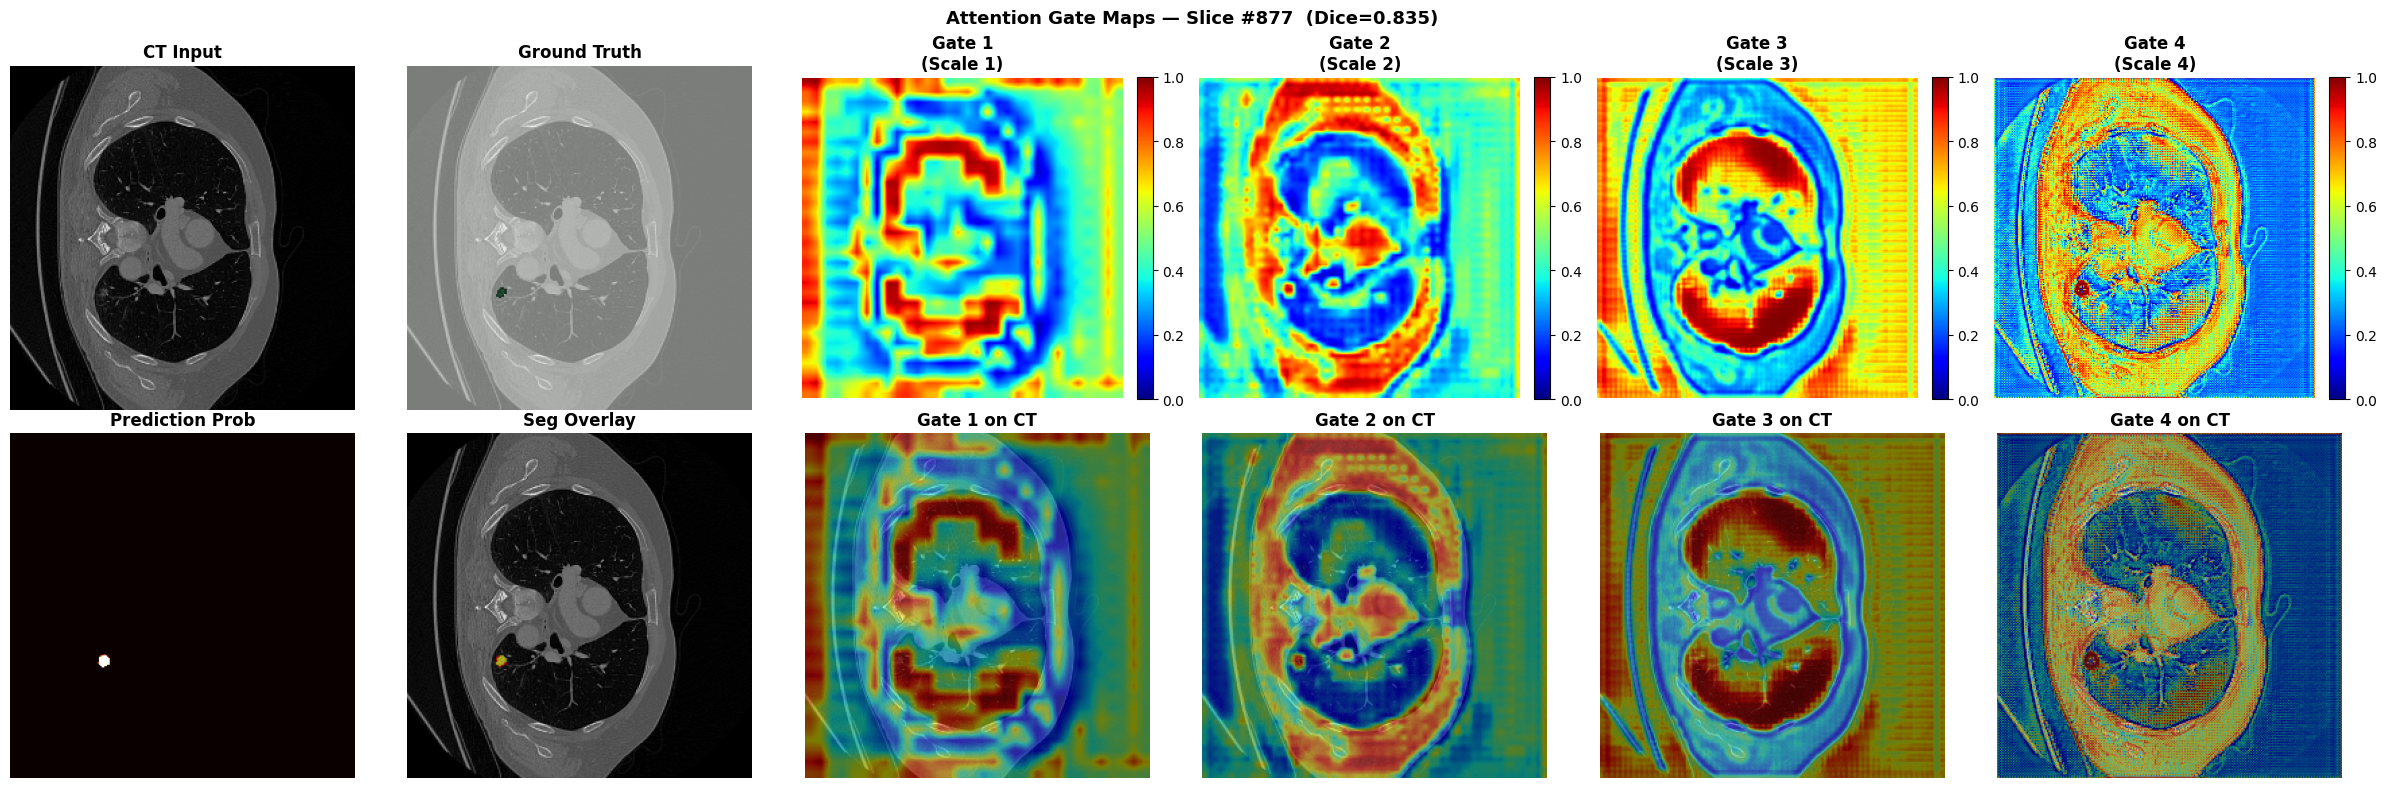

Saved: attention_maps.png


In [10]:
# Pick one good tumour slice for attention visualisation
viz_idx   = tumour_dice[len(tumour_dice)//4][0]  # top-quarter performer
img_t, mask_t = dataset[viz_idx]

activations = {}
def make_hook(name):
    def hook(module, inp, out): activations[name] = out.detach().cpu()
    return hook

handles = [model.att_gates[i].psi.register_forward_hook(make_hook(f'Gate {i+1}'))
           for i in range(len(model.att_gates))]

model.eval()
with torch.no_grad():
    with autocast(enabled=torch.cuda.is_available()):
        logit = model(img_t.unsqueeze(0).to(DEVICE))

for h in handles: h.remove()

prob_viz = torch.sigmoid(logit)[0,0].cpu().numpy()
pred_viz = (prob_viz > THRESHOLD).astype(np.uint8)
mask_viz = mask_t[0].numpy().astype(np.uint8)
img_viz  = img_t[0].numpy()

n_gates = len(activations)
fig, axes = plt.subplots(2, n_gates + 2, figsize=(4*(n_gates+2), 8))
fig.suptitle(f'Attention Gate Maps — Slice #{viz_idx}  (Dice={all_dice[viz_idx]:.3f})',
             fontsize=13, fontweight='bold')

# Top row: input, GT, prediction, then gates
axes[0,0].imshow(img_viz, cmap='gray'); axes[0,0].set_title('CT Input', fontweight='bold')
axes[0,1].imshow(img_viz, cmap='gray')
axes[0,1].imshow(mask_viz, cmap='Greens', alpha=0.5)
axes[0,1].set_title('Ground Truth', fontweight='bold')

for i, (name, att_map) in enumerate(activations.items()):
    am = att_map[0,0].numpy()
    am_up = F.interpolate(
        torch.tensor(am).unsqueeze(0).unsqueeze(0).float(),
        size=img_viz.shape, mode='bilinear', align_corners=False
    )[0,0].numpy()
    im = axes[0, i+2].imshow(am_up, cmap='jet', vmin=0, vmax=1)
    axes[0, i+2].set_title(f'{name}\n(Scale {i+1})', fontweight='bold')
    plt.colorbar(im, ax=axes[0, i+2], fraction=0.046, pad=0.04)

# Bottom row: overlay of each attention map ON the CT
axes[1,0].imshow(prob_viz, cmap='hot', vmin=0, vmax=1)
axes[1,0].set_title('Prediction Prob', fontweight='bold')
axes[1,1].imshow(make_overlay(img_viz, pred_viz, mask_viz))
axes[1,1].set_title('Seg Overlay', fontweight='bold')

for i, (name, att_map) in enumerate(activations.items()):
    am = att_map[0,0].numpy()
    am_up = F.interpolate(
        torch.tensor(am).unsqueeze(0).unsqueeze(0).float(),
        size=img_viz.shape, mode='bilinear', align_corners=False
    )[0,0].numpy()
    axes[1, i+2].imshow(img_viz, cmap='gray')
    im = axes[1, i+2].imshow(am_up, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[1, i+2].set_title(f'{name} on CT', fontweight='bold')

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'attention_maps.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Saved: attention_maps.png')

## 11. Final Summary — Metrics Bar Chart

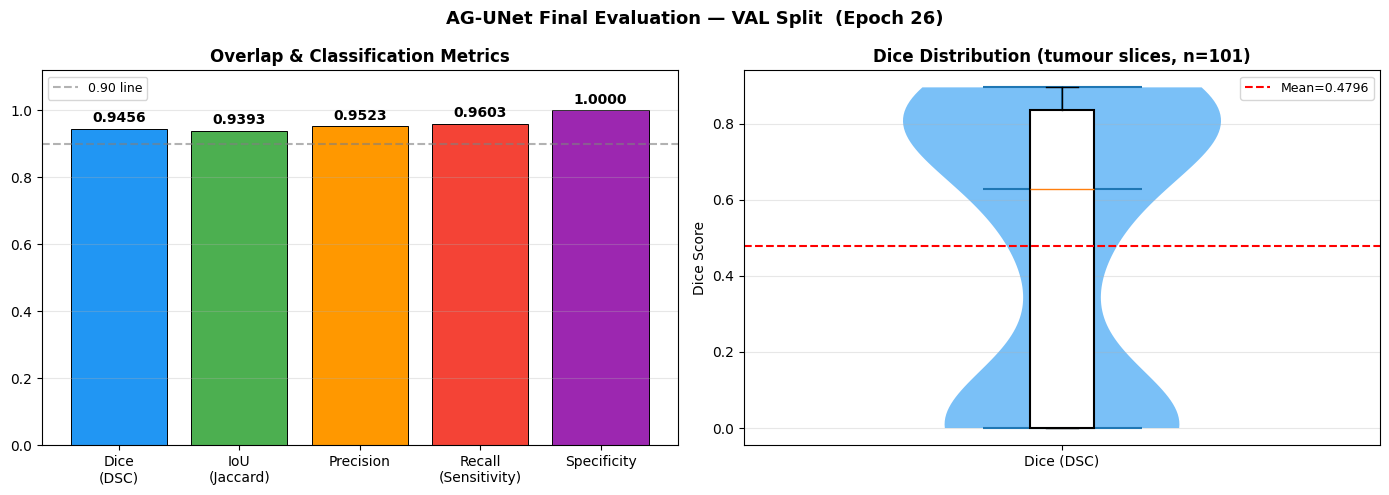


  ALL OUTPUTS SAVED TO: eval_results/
  visual_proof.png       — best/median/worst panels
  failure_cases.png      — 5 worst slices
  attention_maps.png     — gate heatmaps
  metric_distributions.png
  final_summary.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'AG-UNet Final Evaluation — {EVAL_SPLIT.upper()} Split  '
             f'(Epoch {ckpt["epoch"]})', fontsize=13, fontweight='bold')

# Bar chart — overlap metrics
metric_names = ['Dice\n(DSC)', 'IoU\n(Jaccard)', 'Precision', 'Recall\n(Sensitivity)', 'Specificity']
metric_vals  = [results['Dice (DSC)'], results['IoU (Jaccard)'],
                results['Precision'],  results['Recall'],  results['Specificity']]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

bars = axes[0].bar(metric_names, metric_vals, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_ylim(0, 1.12)
axes[0].set_title('Overlap & Classification Metrics', fontweight='bold')
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.6, label='0.90 line')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Dice distribution violin / box
tumour_dice_vals = [all_dice[i] for i in tumour_indices]
vp = axes[1].violinplot([tumour_dice_vals], positions=[1], showmedians=True, showextrema=True)
for pc in vp['bodies']: pc.set_facecolor('#2196F3'); pc.set_alpha(0.6)
axes[1].boxplot([tumour_dice_vals], positions=[1], widths=0.1,
                patch_artist=True, boxprops=dict(facecolor='white', linewidth=1.5))
axes[1].set_xticks([1]); axes[1].set_xticklabels(['Dice (DSC)'])
axes[1].set_title(f'Dice Distribution (tumour slices, n={len(tumour_dice_vals)})', fontweight='bold')
axes[1].set_ylabel('Dice Score')
axes[1].axhline(np.mean(tumour_dice_vals), color='red', linestyle='--',
                label=f'Mean={np.mean(tumour_dice_vals):.4f}')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*52)
print('  ALL OUTPUTS SAVED TO:', OUTPUT_DIR + '/')
print('='*52)
print('  visual_proof.png       — best/median/worst panels')
print('  failure_cases.png      — 5 worst slices')
print('  attention_maps.png     — gate heatmaps')
print('  metric_distributions.png')
print('  final_summary.png')
print('='*52)